## 1. Imports and helper functions

In [1]:
import warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from pandas.plotting import lag_plot
from scipy.stats import jarque_bera, kurtosis, skew
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.dpi']=110
Z = 1.96

def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(actual, predicted)
    return mae, rmse, mape, r2

def grid_search_sarimax(y, exog, ps, ds, qs, Ps, Ds, Qs, s):
    best = (np.inf, None, None)
    for order in itertools.product(ps, ds, qs):
        for sorder in itertools.product(Ps, Ds, Qs, [s]):
            try:
                r = sm.tsa.statespace.SARIMAX(y, exog=exog, order=order, seasonal_order=sorder,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                if np.isfinite(r.aic) and r.aic < best[0]: best = (r.aic, order, sorder)
            except Exception: pass
    return best

def grid_search_arima(y, ps, ds, qs):
    best = (np.inf, None)
    for order in itertools.product(ps, ds, qs):
        try:
            r = sm.tsa.statespace.SARIMAX(y, order=order,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            if np.isfinite(r.aic) and r.aic < best[0]: best = (r.aic, order)
        except Exception: pass
    return best

def se_from_summary(sf):
    return (sf['mean_ci_upper'].values - sf['mean'].values) / Z

def combine_log_components(usd_sf, fx_sf):
    mean_log = usd_sf['mean'].values + fx_sf['mean'].values
    se_tot = np.sqrt(se_from_summary(usd_sf)**2 + se_from_summary(fx_sf)**2)
    return np.exp(mean_log), np.exp(mean_log - Z*se_tot), np.exp(mean_log + Z*se_tot)

def connect(hist_index, hist_values, fc_index, *fc_series):
    new_idx = pd.DatetimeIndex([hist_index[-1]]).append(pd.DatetimeIndex(fc_index))
    out = [new_idx]
    for s in fc_series:
        out.append(np.concatenate([[hist_values[-1]], np.asarray(s)]))
    return tuple(out)

## 2. Load, clean and merge

In [2]:
df_price  = pd.read_csv('DateGlobal_Tea_Price.csv')
df_export = pd.read_csv('Tea_Export_Master_2008_2024.csv')
for col in ['Export Quantity (kg)','Export Price (LKR/kg)','Exchange Rate (LKR/USD)','Export Price (USD/kg)']:
    df_export[col] = pd.to_numeric(df_export[col].astype(str).str.replace(',','',regex=False).str.strip(), errors='coerce')
df_price['Global_Tea_Price ($)'] = pd.to_numeric(df_price['Global_Tea_Price ($)'], errors='coerce')
df = pd.merge(df_price, df_export, on=['Year','Month'])
df['Date'] = pd.to_datetime(df['Year'].astype(str)+'-'+df['Month'], format='%Y-%B')
df = df.set_index('Date').sort_index().drop(columns=['Year','Month']).ffill().bfill()
df.index.freq = 'MS'
df['log_Export_Price_USD'] = np.log(df['Export Price (USD/kg)'])
df['log_Exchange_Rate']    = np.log(df['Exchange Rate (LKR/USD)'])
df['log_Export_Price_LKR'] = np.log(df['Export Price (LKR/kg)'])
df['log_Global_Price']     = np.log(df['Global_Tea_Price ($)'])
print('Shape:', df.shape, '| nulls:', int(df.isnull().sum().sum()))
df.head()

Shape: (204, 9) | nulls: 0


,Global_Tea_Price ($),Export Quantity (kg),Export Price (LKR/kg),Exchange Rate (LKR/USD),Export Price (USD/kg),log_Export_Price_USD,log_Exchange_Rate,log_Export_Price_LKR,log_Global_Price
Date,,,,,,,,,
2008-01-01,2.38,25100000.0,385.12,108.166956,3.560422,1.269879,4.683676,5.953555,0.867100
2008-02-01,2.40,23850000.0,398.40,107.845238,3.694183,1.306759,4.680697,5.987457,0.875469
2008-03-01,2.26,27200000.0,412.55,107.731905,3.829413,1.342712,4.679646,6.022357,0.815365
2008-04-01,2.49,21400000.0,425.30,107.803182,3.945153,1.372488,4.680307,6.052795,0.912283
2008-05-01,2.48,28500000.0,438.10,107.787273,4.064487,1.402288,4.680160,6.082447,0.908259


# 3. Exploratory Data Analysis (visual)

## 3.1 Variables over time

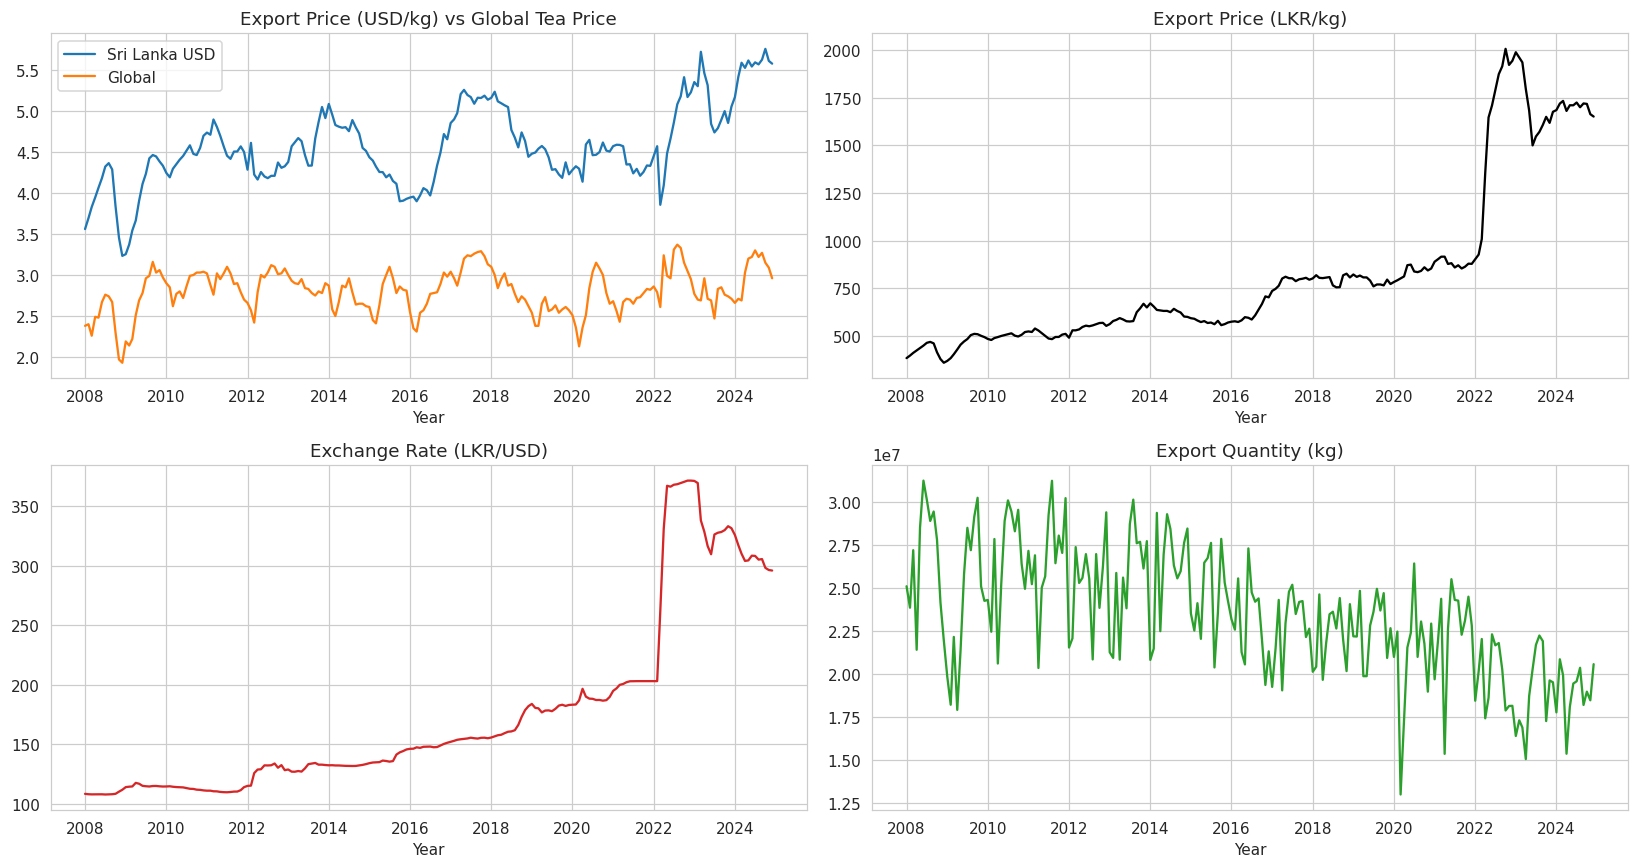

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(15,8))
ax[0,0].plot(df.index, df['Export Price (USD/kg)'], label='Sri Lanka USD', color='tab:blue')
ax[0,0].plot(df.index, df['Global_Tea_Price ($)'], label='Global', color='tab:orange')
ax[0,0].set_title('Export Price (USD/kg) vs Global Tea Price'); ax[0,0].legend()
ax[0,1].plot(df.index, df['Export Price (LKR/kg)'], color='black')
ax[0,1].set_title('Export Price (LKR/kg)')
ax[1,0].plot(df.index, df['Exchange Rate (LKR/USD)'], color='tab:red')
ax[1,0].set_title('Exchange Rate (LKR/USD)')
ax[1,1].plot(df.index, df['Export Quantity (kg)'], color='tab:green')
ax[1,1].set_title('Export Quantity (kg)')
for a in ax.ravel(): a.set_xlabel('Year')
plt.tight_layout(); plt.show()

## 3.2 Distributions of key variables

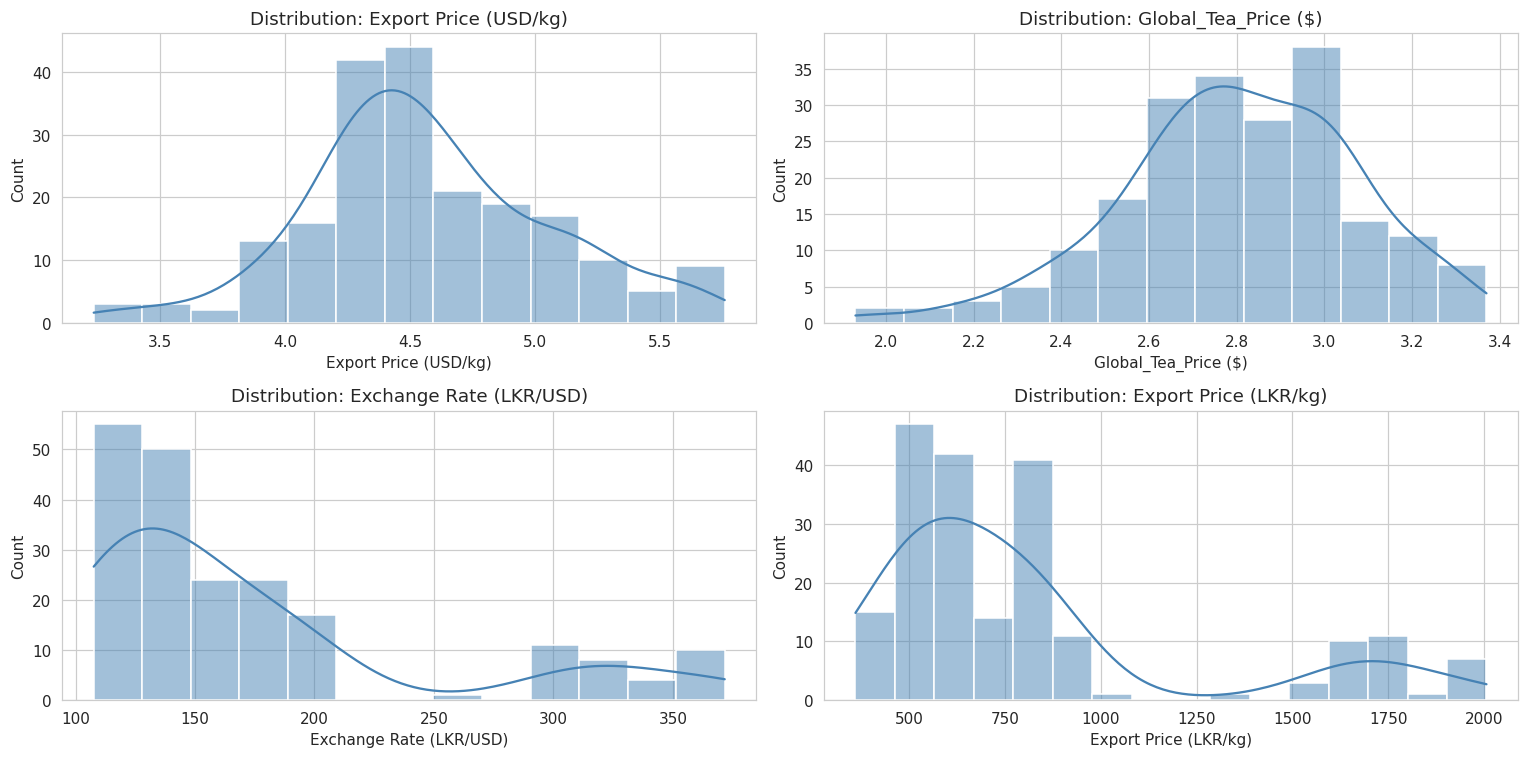

In [4]:
cols = ['Export Price (USD/kg)','Global_Tea_Price ($)','Exchange Rate (LKR/USD)','Export Price (LKR/kg)']
fig, ax = plt.subplots(2, 2, figsize=(14,7))
for a, c in zip(ax.ravel(), cols):
    sns.histplot(df[c], kde=True, ax=a, color='steelblue')
    a.set_title(f'Distribution: {c}')
plt.tight_layout(); plt.show()

## 3.3 Correlation matrix (heatmap)
Quantifies the linear relationships between the macro indicators. Look for the USD-price vs global-price correlation and the exchange-rate vs quantity sign.

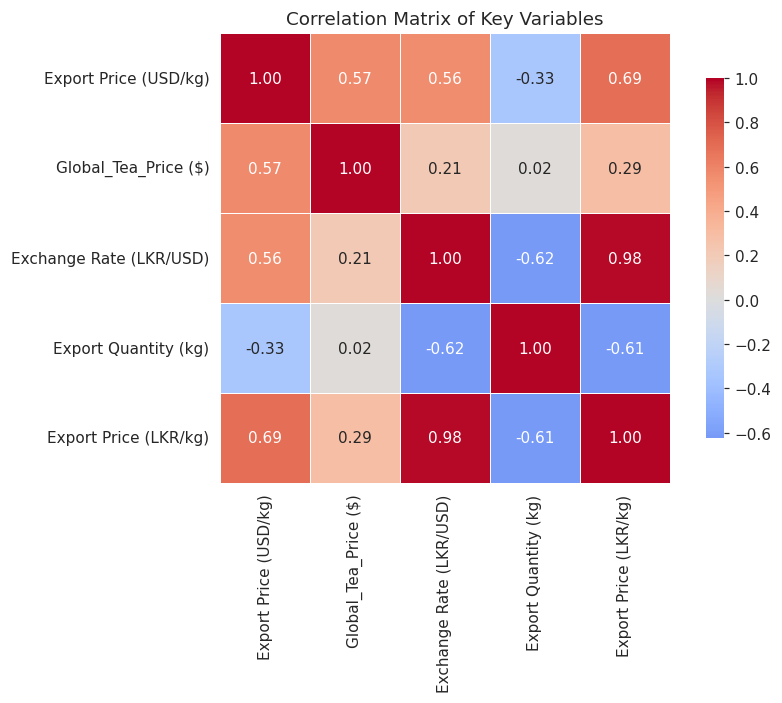

USD price vs Global price: 0.573
Exchange rate vs Quantity: -0.624


In [5]:
corr_cols = ['Export Price (USD/kg)','Global_Tea_Price ($)','Exchange Rate (LKR/USD)',
             'Export Quantity (kg)','Export Price (LKR/kg)']
corr = df[corr_cols].corr()
plt.figure(figsize=(8.5,6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={'shrink':.8})
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout(); plt.show()
print('USD price vs Global price:', round(corr.loc['Export Price (USD/kg)','Global_Tea_Price ($)'],3))
print('Exchange rate vs Quantity:', round(corr.loc['Exchange Rate (LKR/USD)','Export Quantity (kg)'],3))

## 3.4 Feature relationships (scatter)

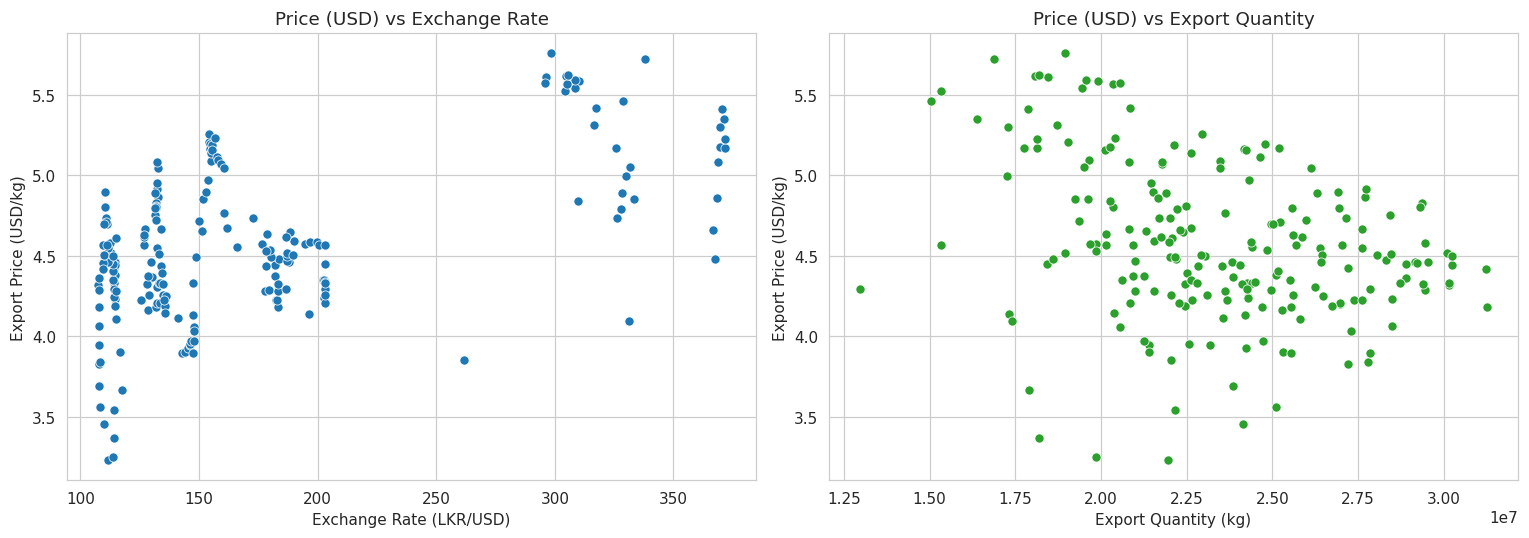

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(x=df['Exchange Rate (LKR/USD)'], y=df['Export Price (USD/kg)'], ax=ax[0], color='tab:blue')
ax[0].set_title('Price (USD) vs Exchange Rate')
sns.scatterplot(x=df['Export Quantity (kg)'], y=df['Export Price (USD/kg)'], ax=ax[1], color='tab:green')
ax[1].set_title('Price (USD) vs Export Quantity')
plt.tight_layout(); plt.show()

## 3.5 Seasonal decomposition
Splits the USD price into trend, seasonal and residual components — confirms the upward **trend** (motivating differencing) and shows how weak/strong **seasonality** is.

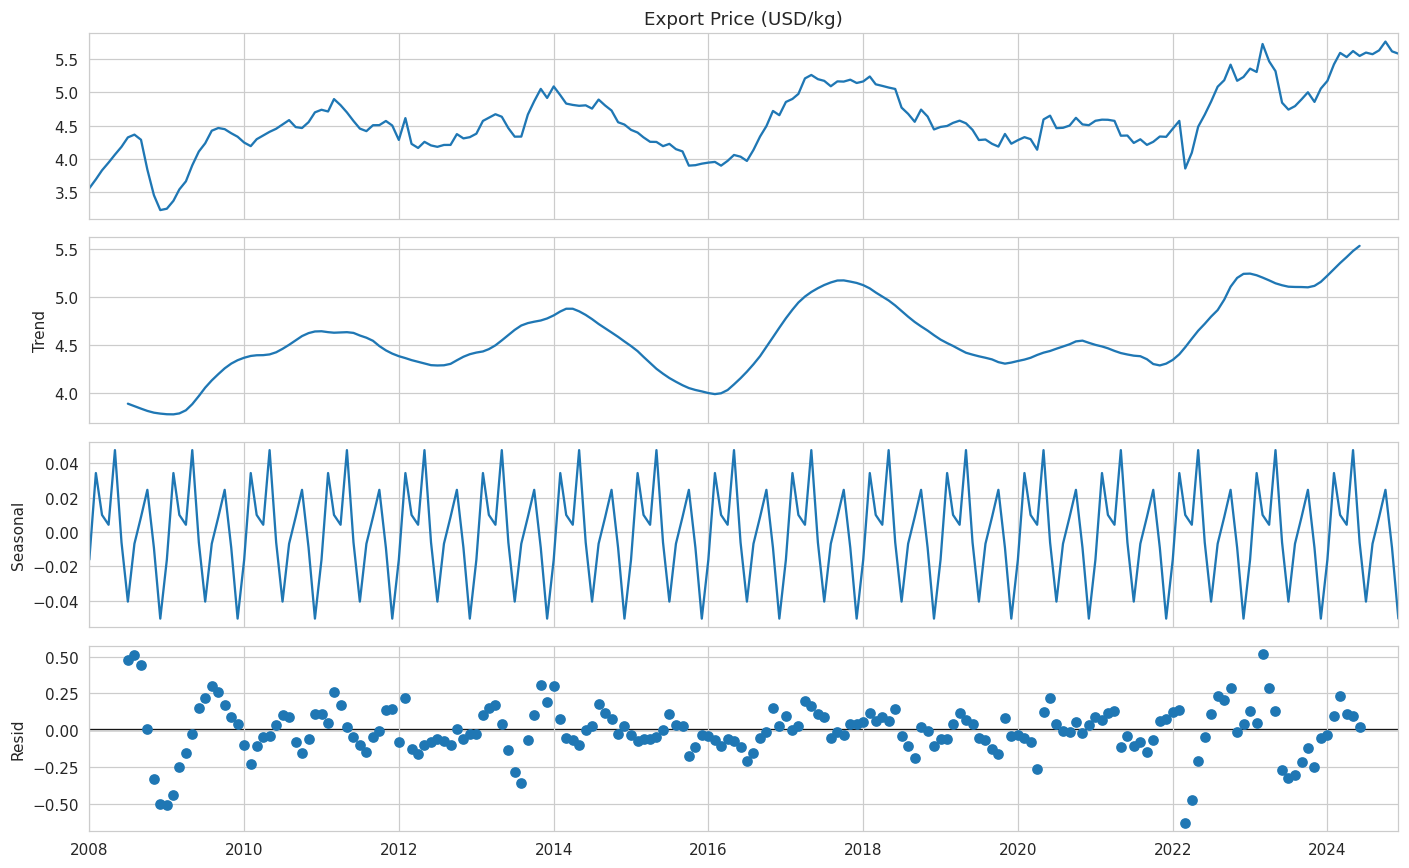

In [7]:
decomp = seasonal_decompose(df['Export Price (USD/kg)'], model='additive', period=12)
fig = decomp.plot(); fig.set_size_inches(13,8)
plt.tight_layout(); plt.show()

## 3.6 Lag plot (persistence)
Each month's value against the next month's. A tight diagonal cloud ⇒ strong autocorrelation ⇒ an AR term is justified.

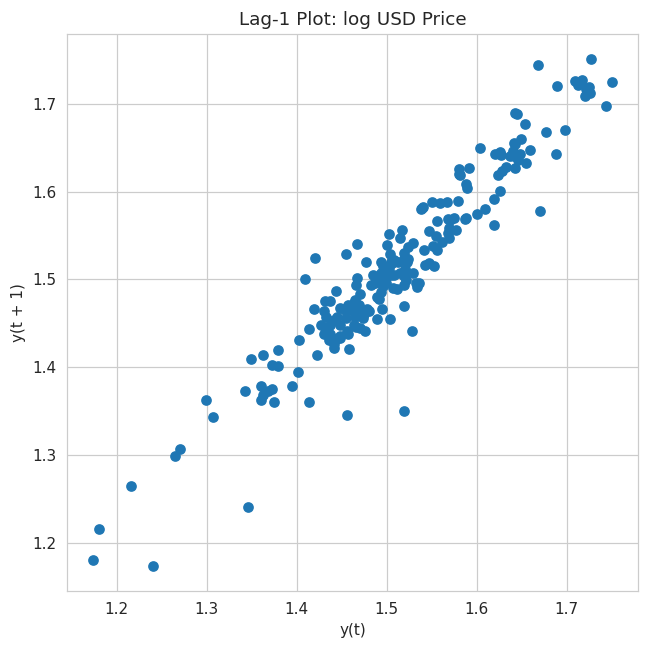

In [8]:
plt.figure(figsize=(6,6))
lag_plot(df['log_Export_Price_USD'], lag=1)
plt.title('Lag-1 Plot: log USD Price'); plt.tight_layout(); plt.show()

# 4. Stationarity, volatility and model identification

## 4.1 Log returns and ADF test

ADF statistic = -12.016, p-value = 0.0000 -> stationary


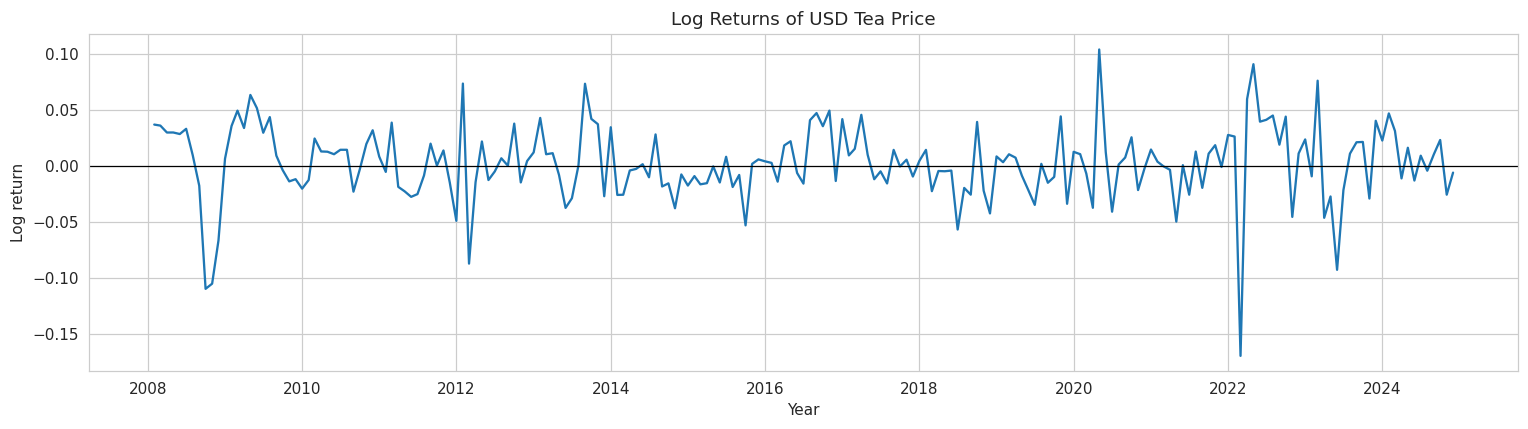

In [9]:
returns = df['log_Export_Price_USD'].diff().dropna()
stat, p, *_ = adfuller(returns)
print(f'ADF statistic = {stat:.3f}, p-value = {p:.4f} ->', 'stationary' if p<0.05 else 'non-stationary')
plt.figure(figsize=(14,4))
plt.plot(returns.index, returns, color='tab:blue')
plt.axhline(0, color='black', lw=.8)
plt.title('Log Returns of USD Tea Price'); plt.xlabel('Year'); plt.ylabel('Log return')
plt.tight_layout(); plt.show()

## 4.2 Rolling volatility (12-month)

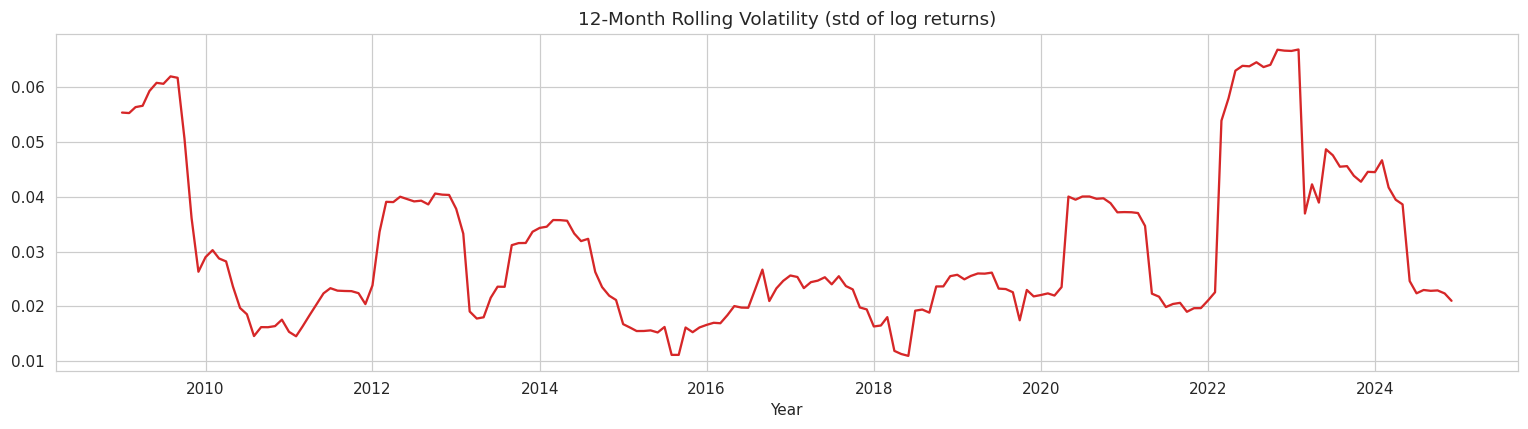

In [10]:
roll_vol = returns.rolling(12).std()
plt.figure(figsize=(14,4))
plt.plot(roll_vol.index, roll_vol, color='tab:red')
plt.title('12-Month Rolling Volatility (std of log returns)'); plt.xlabel('Year')
plt.tight_layout(); plt.show()

## 4.3 ACF and PACF
Read the moving-average order **q** from the ACF and the autoregressive order **p** from the PACF (significant spikes before the bars fall inside the shaded band).

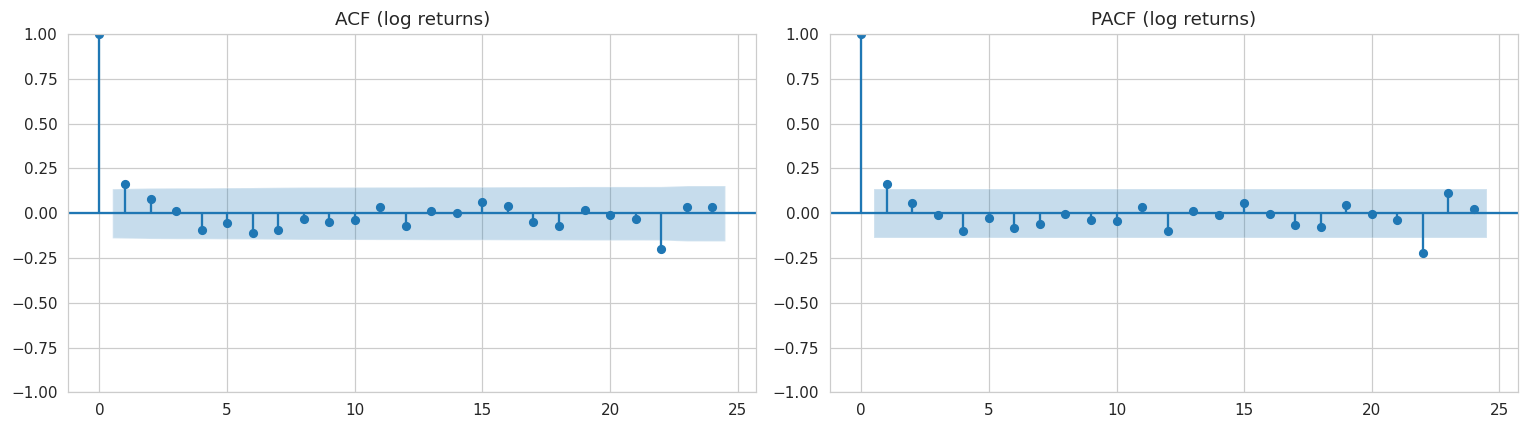

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
plot_acf(returns, lags=24, ax=ax[0]); ax[0].set_title('ACF (log returns)')
plot_pacf(returns, lags=24, ax=ax[1], method='ywm'); ax[1].set_title('PACF (log returns)')
plt.tight_layout(); plt.show()

# 5. Correction 1 — choose model orders by AIC grid search
*The USD search fits ~144 models and may take a minute.*

In [12]:
y_usd = df['log_Export_Price_USD']; exog_usd = df[['log_Global_Price']]
aic_usd, order_usd, sorder_usd = grid_search_sarimax(
    y_usd, exog_usd, ps=[0,1,2], ds=[0,1], qs=[0,1,2], Ps=[0,1], Ds=[0,1], Qs=[0,1], s=12)
print(f'USD  -> SARIMAX{order_usd}{sorder_usd}   AIC={aic_usd:.2f}')
aic_fx, order_fx = grid_search_arima(df['log_Exchange_Rate'], [0,1,2,3],[0,1],[0,1,2,3])
print(f'FX   -> ARIMA{order_fx}   AIC={aic_fx:.2f}')
aic_g, order_g = grid_search_arima(df['log_Global_Price'], [0,1,2,3],[0,1],[0,1,2,3])
print(f'GLOB -> ARIMA{order_g}   AIC={aic_g:.2f}')

USD  -> SARIMAX(1, 0, 0)(0, 0, 0, 12)   AIC=-810.46
FX   -> ARIMA(2, 0, 1)   AIC=-922.01
GLOB -> ARIMA(1, 1, 2)   AIC=-626.46


### 5.1 Fit the selected models

In [13]:
results_usd = sm.tsa.statespace.SARIMAX(y_usd, exog=exog_usd, order=order_usd, seasonal_order=sorder_usd,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
results_fx  = sm.tsa.statespace.SARIMAX(df['log_Exchange_Rate'], order=order_fx,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
results_glob = sm.tsa.statespace.SARIMAX(df['log_Global_Price'], order=order_g,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(results_usd.summary())

                                SARIMAX Results                                 
Dep. Variable:     log_Export_Price_USD   No. Observations:                  204
Model:                 SARIMAX(1, 0, 0)   Log Likelihood                 408.228
Date:                  Mon, 29 Jun 2026   AIC                           -810.455
Time:                          08:46:59   BIC                           -800.516
Sample:                      01-01-2008   HQIC                          -806.434
                           - 12-01-2024                                         
Covariance Type:                    opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
log_Global_Price     0.1588      0.038      4.164      0.000       0.084       0.234
ar.L1                1.0012      0.002    561.880      0.000       0.998       1.005
sigma2      

### 5.2 SARIMAX & ARIMA in-sample fits (visual)
How closely each component model tracks its series in-sample.

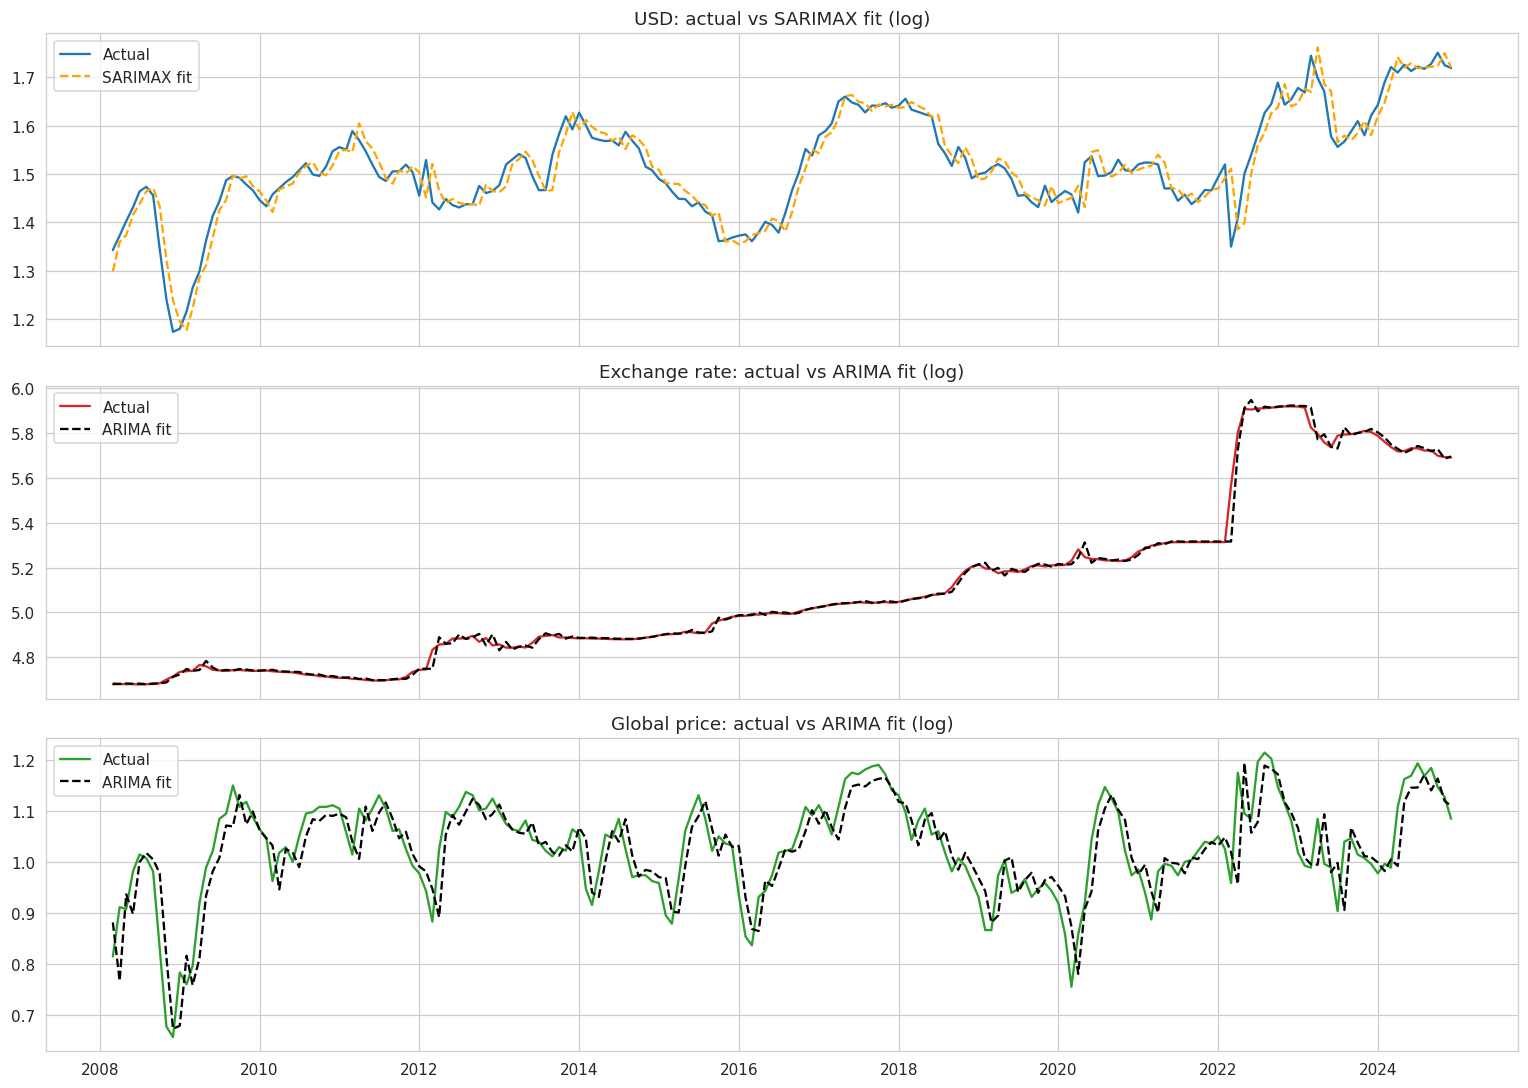

In [14]:
df['usd_forecast'] = results_usd.predict(start=0, end=len(df)-1, exog=exog_usd)
df['fx_forecast']  = results_fx.predict(start=0, end=len(df)-1)
glob_fit = results_glob.predict(start=0, end=len(df)-1)

fig, ax = plt.subplots(3, 1, figsize=(14,10), sharex=True)
ax[0].plot(df.index[2:], df['log_Export_Price_USD'][2:], label='Actual', color='tab:blue')
ax[0].plot(df.index[2:], df['usd_forecast'][2:], '--', label='SARIMAX fit', color='orange')
ax[0].set_title('USD: actual vs SARIMAX fit (log)'); ax[0].legend()
ax[1].plot(df.index[2:], df['log_Exchange_Rate'][2:], label='Actual', color='tab:red')
ax[1].plot(df.index[2:], df['fx_forecast'][2:], '--', label='ARIMA fit', color='black')
ax[1].set_title('Exchange rate: actual vs ARIMA fit (log)'); ax[1].legend()
ax[2].plot(df.index[2:], df['log_Global_Price'][2:], label='Actual', color='tab:green')
ax[2].plot(df.index[2:], glob_fit[2:], '--', label='ARIMA fit', color='black')
ax[2].set_title('Global price: actual vs ARIMA fit (log)'); ax[2].legend()
plt.tight_layout(); plt.show()

## 6. Correction 5 — honest residual diagnostics

Ljung-Box(12)  p = 0.658 -> no leftover autocorrelation (good)
Jarque-Bera    p = 4.27e-22 -> NON-normal
Skew = -0.58  Kurtosis = 6.22 (normal=3)

If Ljung-Box passes but Jarque-Bera fails with high kurtosis: dynamics captured, but fat-tailed
errors -> 95% intervals likely UNDERSTATE tail risk in volatile periods (e.g. 2022).


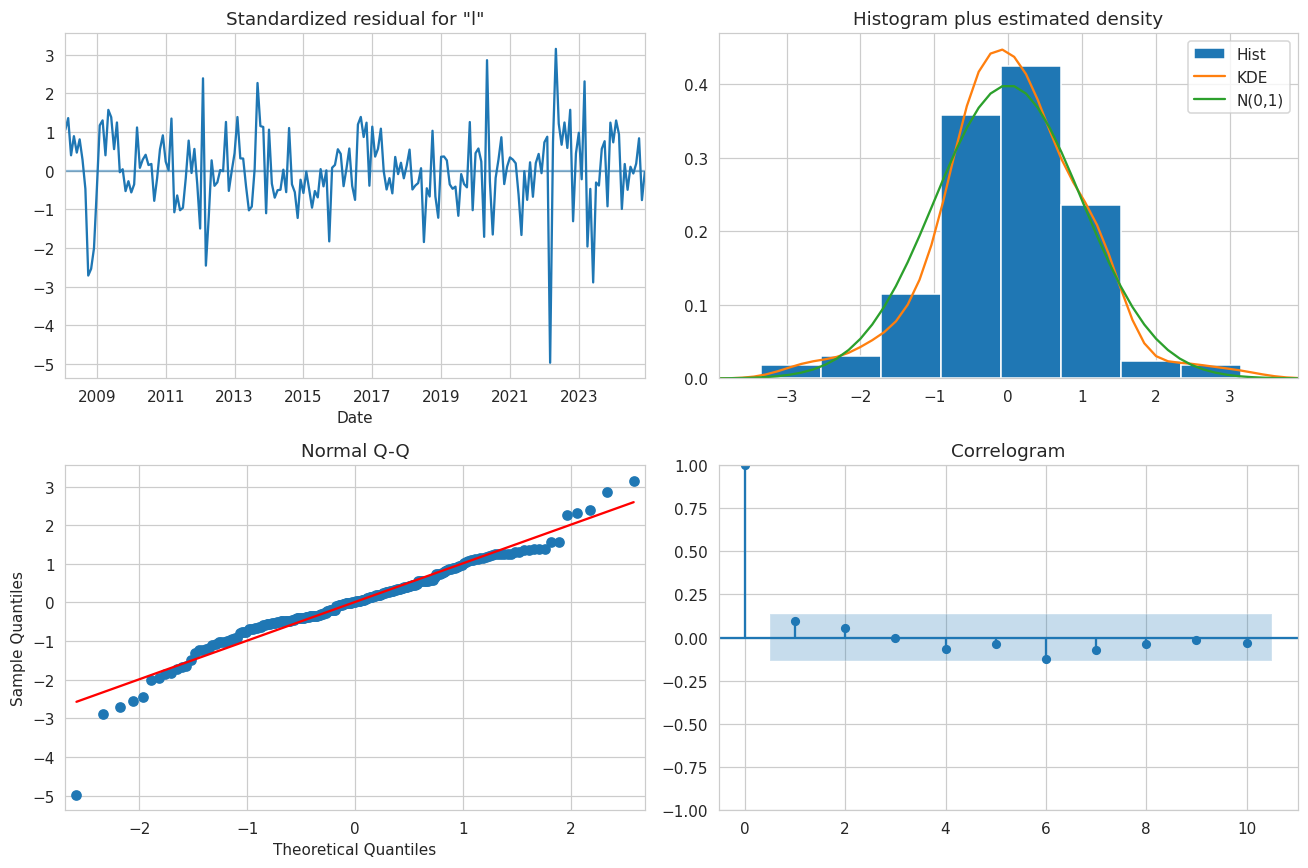

In [15]:
resid = results_usd.resid[2:]
lb = acorr_ljungbox(resid, lags=[12], return_df=True)
jb_stat, jb_p = jarque_bera(resid)
print(f"Ljung-Box(12)  p = {lb['lb_pvalue'].iloc[0]:.3f} -> "
      f"{'no leftover autocorrelation (good)' if lb['lb_pvalue'].iloc[0]>.05 else 'autocorrelation remains'}")
print(f"Jarque-Bera    p = {jb_p:.3g} -> {'~ normal' if jb_p>.05 else 'NON-normal'}")
print(f"Skew = {skew(resid):.2f}  Kurtosis = {kurtosis(resid, fisher=False):.2f} (normal=3)")
print('\nIf Ljung-Box passes but Jarque-Bera fails with high kurtosis: dynamics captured, but fat-tailed')
print('errors -> 95% intervals likely UNDERSTATE tail risk in volatile periods (e.g. 2022).')
results_usd.plot_diagnostics(figsize=(12,8)); plt.tight_layout(); plt.show()

## 7. Component decomposition: USD + FX → LKR
Shows how the two forecast components add (in log space) to reconstruct the rupee price, making clear how much of the LKR move comes from FX depreciation vs the USD price.

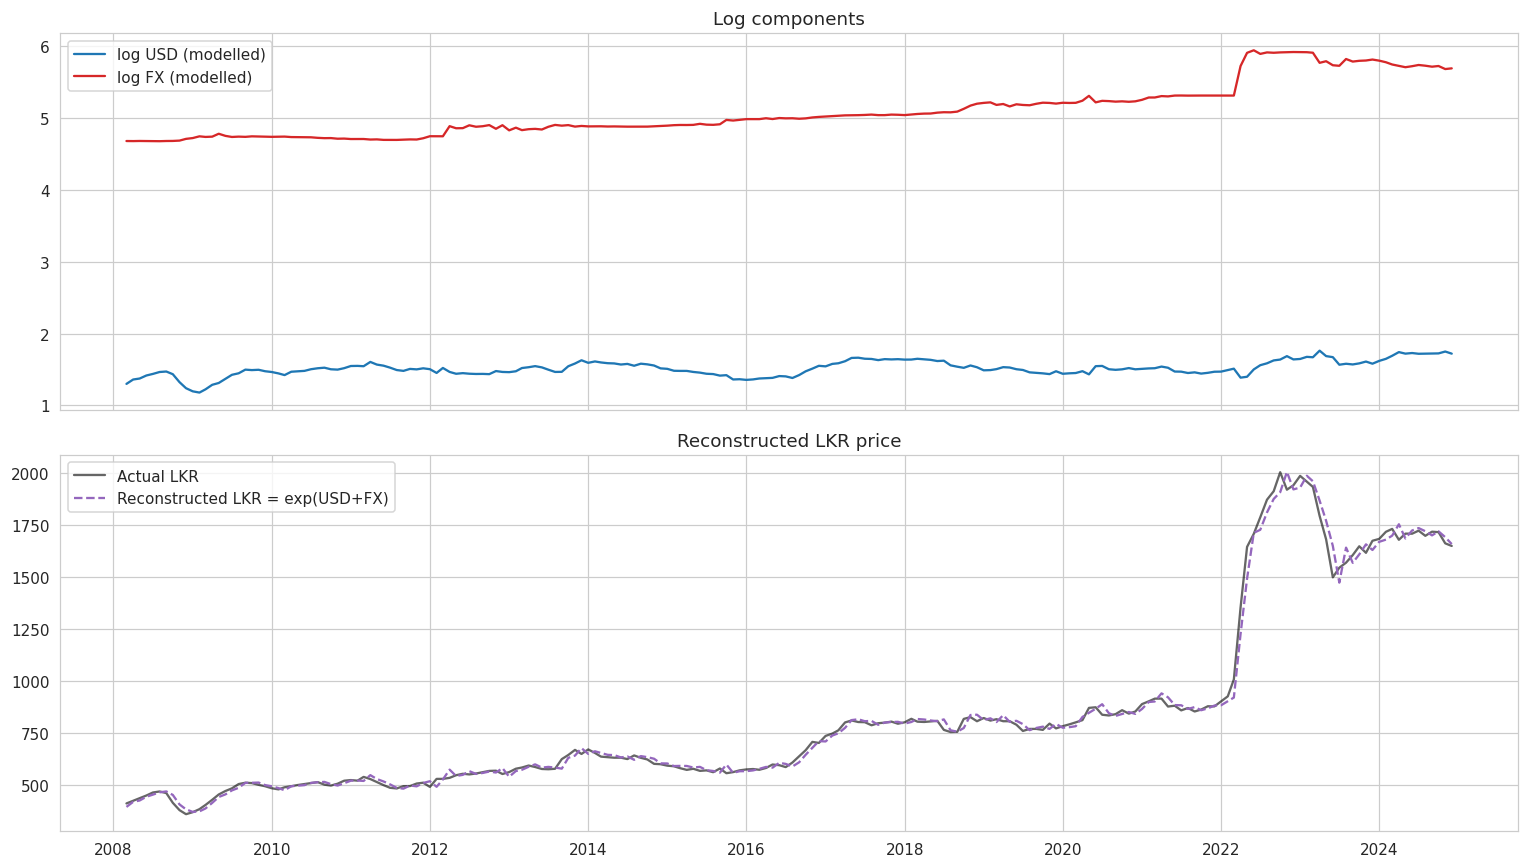

In [16]:
df['lkr_forecast_real'] = np.exp(df['usd_forecast'] + df['fx_forecast'])
fig, ax = plt.subplots(2, 1, figsize=(14,8), sharex=True)
ax[0].plot(df.index[2:], df['usd_forecast'][2:], label='log USD (modelled)', color='tab:blue')
ax[0].plot(df.index[2:], df['fx_forecast'][2:], label='log FX (modelled)', color='tab:red')
ax[0].set_title('Log components'); ax[0].legend()
ax[1].plot(df.index[2:], df['Export Price (LKR/kg)'][2:], label='Actual LKR', color='black', alpha=.6)
ax[1].plot(df.index[2:], df['lkr_forecast_real'][2:], '--', label='Reconstructed LKR = exp(USD+FX)', color='tab:purple')
ax[1].set_title('Reconstructed LKR price'); ax[1].legend()
plt.tight_layout(); plt.show()

## 8. In-sample period-wise evaluation (SARIMAX hybrid)

In [17]:
mask = df.index[2:]
periods = [('Overall', mask), ('Pre-2022', mask[mask<'2022-01-01']), ('Post-2022', mask[mask>='2022-01-01'])]
print(f'{"Period":<12}| {"MAE":>8} | {"RMSE":>8} | {"MAPE":>7} | {"R2":>7}'); print('-'*52)
for label, m in periods:
    mae,rmse,mape,r2 = calculate_metrics(df.loc[m,'Export Price (LKR/kg)'], df.loc[m,'lkr_forecast_real'])
    print(f'{label:<12}| {mae:>8.2f} | {rmse:>8.2f} | {mape:>6.2f}% | {r2:>7.4f}')

Period      |      MAE |     RMSE |    MAPE |      R2
----------------------------------------------------
Overall     |    19.93 |    30.81 |   2.32% |  0.9948
Pre-2022    |    13.41 |    17.17 |   2.15% |  0.9863
Post-2022   |    50.02 |    63.00 |   3.13% |  0.9403


## 9. Corrections 2 & 3 — out-of-sample forecast (forecasted global price + variance-combined CI)

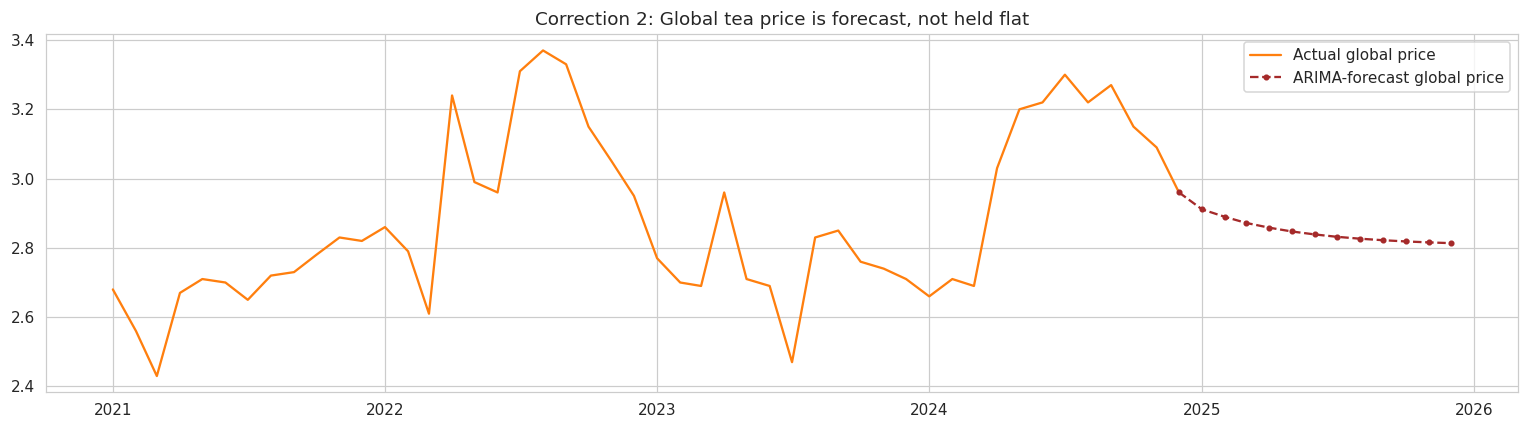

,forecast_LKR,lower95,upper95
2025-01-01,1652.70,1526.79,1788.99
2025-02-01,1660.47,1461.86,1886.07
2025-03-01,1670.09,1412.88,1974.13
2025-04-01,1680.62,1374.45,2054.99
2025-05-01,1691.67,1343.19,2130.57
2025-06-01,1703.09,1316.98,2202.39
2025-07-01,1714.79,1294.50,2271.53
2025-08-01,1726.73,1274.86,2338.75
2025-09-01,1738.87,1257.46,2404.58
2025-10-01,1751.20,1241.87,2469.43


In [18]:
steps = 12
glob_oos = results_glob.get_forecast(steps=steps).summary_frame()
future_exog = pd.DataFrame({'log_Global_Price': glob_oos['mean'].values}, index=glob_oos.index)
usd_oos = results_usd.get_forecast(steps=steps, exog=future_exog).summary_frame()
fx_oos  = results_fx.get_forecast(steps=steps).summary_frame()
lkr_sarimax, lkr_sarimax_lo, lkr_sarimax_hi = combine_log_components(usd_oos, fx_oos)
forecast_index = usd_oos.index

# Visualize the forecasted global price (Correction 2) connected to history
g_hist = df['Global_Tea_Price ($)']
gi, gv = connect(g_hist.index, g_hist.values, glob_oos.index, np.exp(glob_oos['mean'].values))
plt.figure(figsize=(14,4))
plt.plot(df.index[-48:], g_hist.iloc[-48:], color='tab:orange', label='Actual global price')
plt.plot(gi, gv, '--o', color='brown', markersize=3, label='ARIMA-forecast global price')
plt.title('Correction 2: Global tea price is forecast, not held flat'); plt.legend(); plt.tight_layout(); plt.show()

pd.DataFrame({'forecast_LKR':lkr_sarimax.round(2),'lower95':lkr_sarimax_lo.round(2),
              'upper95':lkr_sarimax_hi.round(2)}, index=forecast_index)

### 9.1 Correction 4 — SARIMAX forecast connected to history

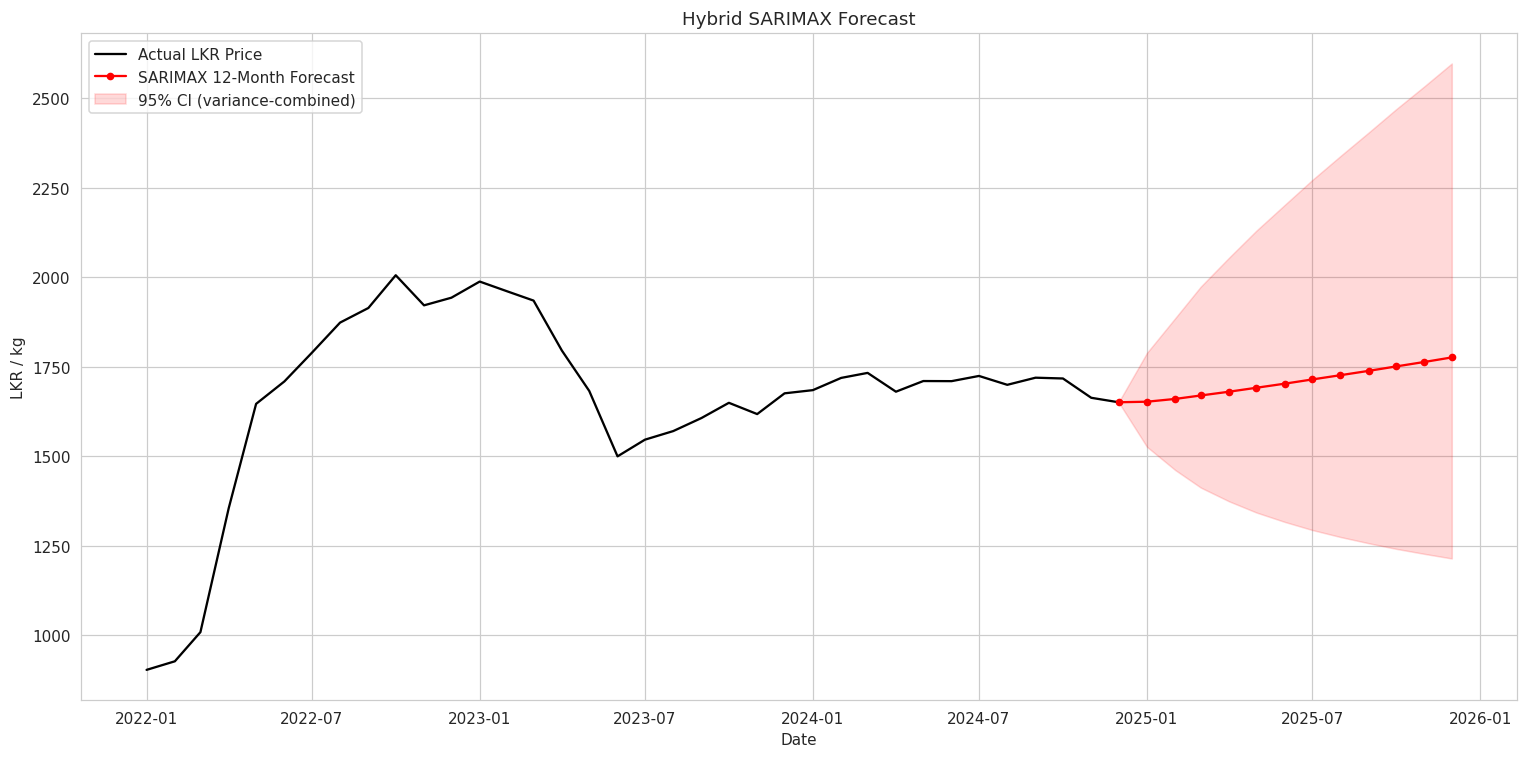

In [19]:
hist = df['Export Price (LKR/kg)']
ci, cv = connect(hist.index, hist.values, forecast_index, lkr_sarimax)
_, clo = connect(hist.index, hist.values, forecast_index, lkr_sarimax_lo)
_, chi = connect(hist.index, hist.values, forecast_index, lkr_sarimax_hi)
plt.figure(figsize=(14,7))
plt.plot(df.index[-36:], hist.iloc[-36:], color='black', label='Actual LKR Price')
plt.plot(ci, cv, color='red', marker='o', markersize=4, label='SARIMAX 12-Month Forecast')
plt.fill_between(ci, clo, chi, color='red', alpha=0.15, label='95% CI (variance-combined)')
plt.title('Hybrid SARIMAX Forecast'); plt.xlabel('Date'); plt.ylabel('LKR / kg')
plt.legend(loc='upper left'); plt.tight_layout(); plt.show()

## 10. Hybrid XGBoost (USD component)
Models log-differences with engineered features, validated walk-forward; recursive OOS uses the forecasted global price.

In [20]:
import xgboost as xgb
df_xgb = df[['log_Export_Price_USD','log_Global_Price']].copy()
df_xgb['target'] = df_xgb['log_Export_Price_USD'].diff()
for l in [1,2,3,12]:
    df_xgb[f'lag_{l}']=df_xgb['log_Export_Price_USD'].shift(l)
    df_xgb[f'global_lag_{l}']=df_xgb['log_Global_Price'].shift(l)
df_xgb['rolling_mean_3']=df_xgb['log_Export_Price_USD'].shift(1).rolling(3).mean()
df_xgb['rolling_std_3'] =df_xgb['log_Export_Price_USD'].shift(1).rolling(3).std()
df_xgb['month']=df_xgb.index.month
df_xgb['sin_month']=np.sin(2*np.pi*df_xgb['month']/12); df_xgb['cos_month']=np.cos(2*np.pi*df_xgb['month']/12)
df_xgb=df_xgb.dropna()
features=[c for c in df_xgb.columns if c not in ['target','log_Export_Price_USD','log_Global_Price','month']]
X,yv=df_xgb[features],df_xgb['target']; n_obs=len(df_xgb); train_size=int(n_obs*0.7)
pred_diff=[]
for t in range(train_size,n_obs):
    mdl=xgb.XGBRegressor(n_estimators=100,learning_rate=0.05,max_depth=3,random_state=42)
    mdl.fit(X.iloc[:t],yv.iloc[:t]); pred_diff.append(mdl.predict(X.iloc[t:t+1])[0])
idx=df_xgb.index[train_size:]
recon=[df_xgb['log_Export_Price_USD'].iloc[train_size+i-1]+d for i,d in enumerate(pred_diff)]
xgb_lkr=np.exp(np.array(recon)+df.loc[idx,'log_Exchange_Rate'].values)
print(f'{"Period":<16}| {"MAE":>8} | {"RMSE":>8} | {"MAPE":>7} | {"R2":>7}'); print('-'*56)
for label,m in [('Overall (Test)',idx),('Pre-2022 (Test)',idx[idx<'2022-01-01']),('Post-2022 (Test)',idx[idx>='2022-01-01'])]:
    if len(m)==0: continue
    s=np.where(idx==m[0])[0][0]; e=np.where(idx==m[-1])[0][0]+1
    mae,rmse,mape,r2=calculate_metrics(df.loc[m,'Export Price (LKR/kg)'], xgb_lkr[s:e])
    print(f'{label:<16}| {mae:>8.2f} | {rmse:>8.2f} | {mape:>6.2f}% | {r2:>7.4f}')

Period          |      MAE |     RMSE |    MAPE |      R2
--------------------------------------------------------
Overall (Test)  |    41.82 |    57.80 |   2.98% |  0.9826
Pre-2022 (Test) |    17.57 |    26.80 |   2.05% |  0.1173
Post-2022 (Test)|    56.63 |    70.31 |   3.55% |  0.9256


### 10.1 XGBoost walk-forward fit and feature importance

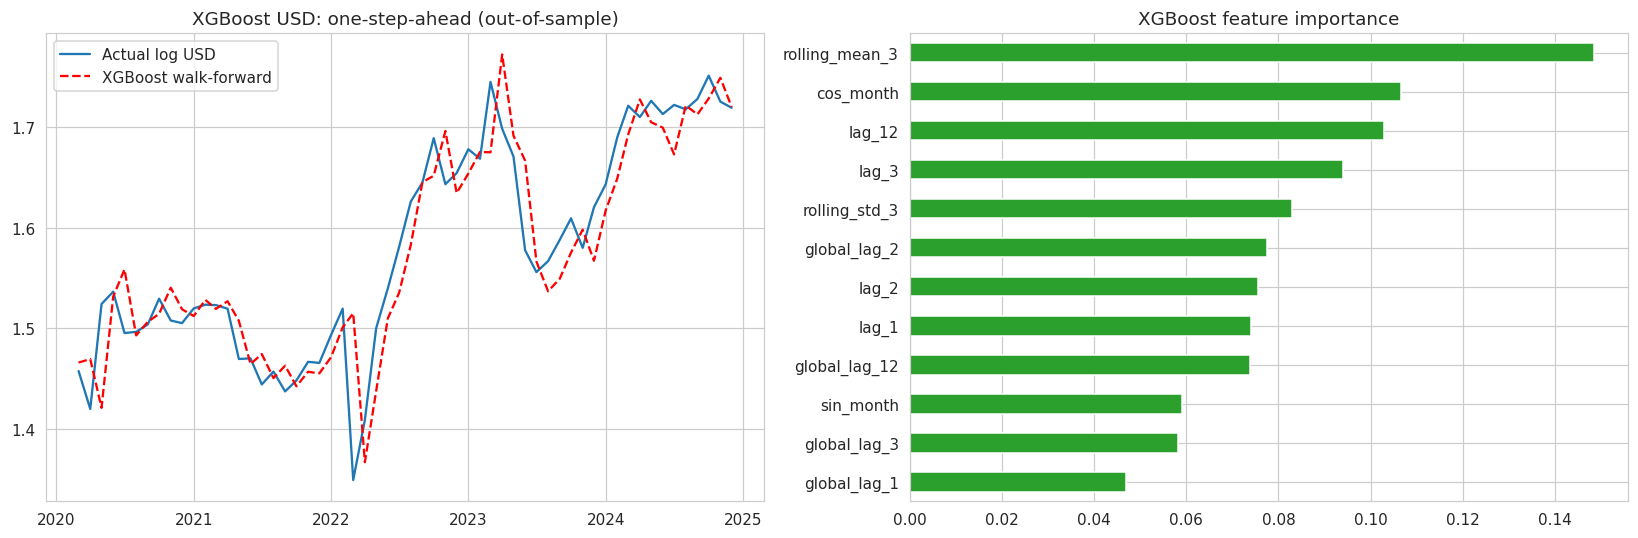

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
ax[0].plot(idx, df_xgb['log_Export_Price_USD'].iloc[train_size:], label='Actual log USD', color='tab:blue')
ax[0].plot(idx, recon, '--', label='XGBoost walk-forward', color='red')
ax[0].set_title('XGBoost USD: one-step-ahead (out-of-sample)'); ax[0].legend()
fi = pd.Series(xgb.XGBRegressor(n_estimators=100,learning_rate=0.05,max_depth=3,random_state=42)
               .fit(X,yv).feature_importances_, index=features).sort_values()
fi.plot(kind='barh', ax=ax[1], color='tab:green'); ax[1].set_title('XGBoost feature importance')
plt.tight_layout(); plt.show()

### 10.2 XGBoost recursive 12-month forecast (connected)

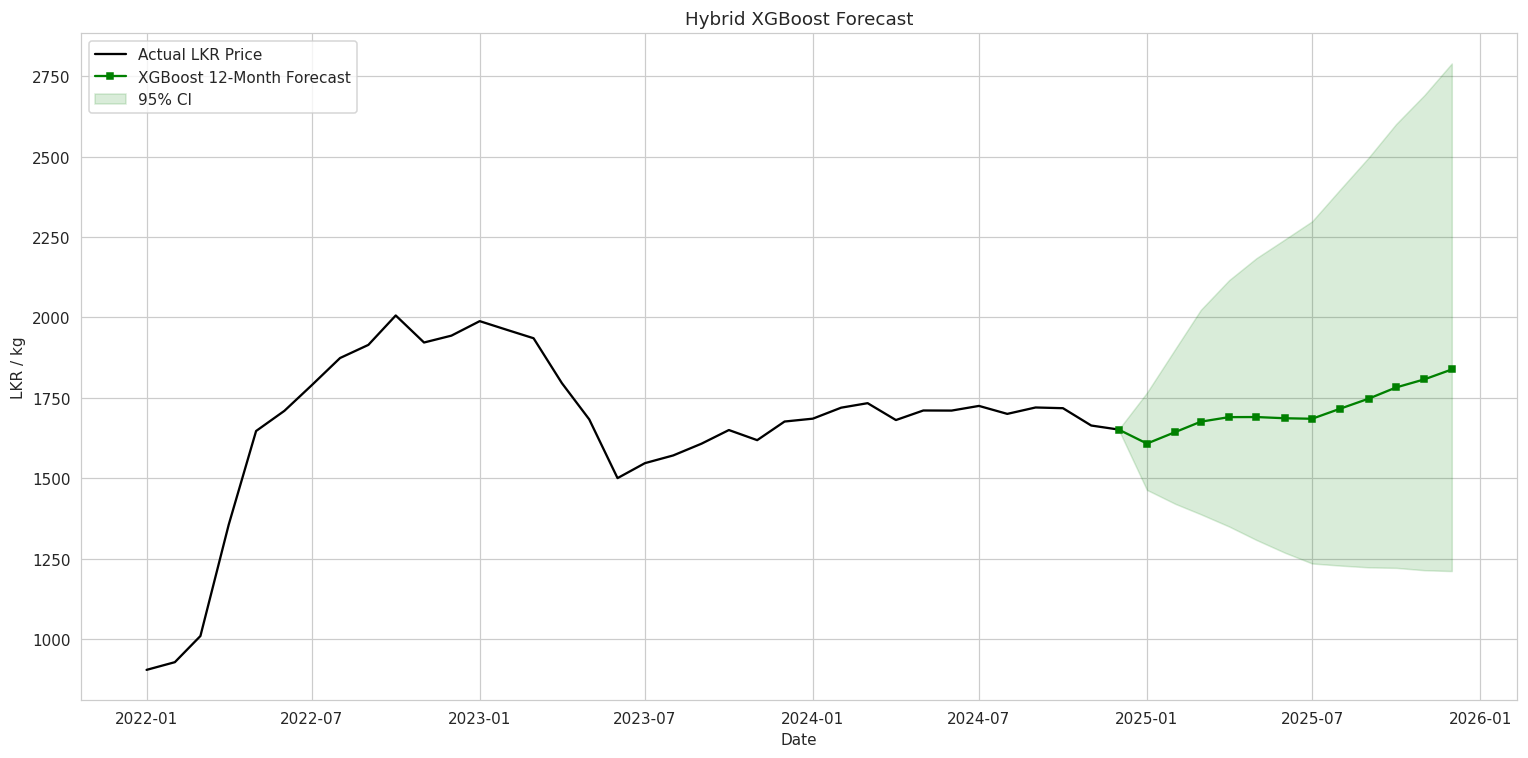

In [22]:
future_dates = pd.date_range(df.index[-1]+pd.DateOffset(months=1), periods=steps, freq='MS')
final_model = xgb.XGBRegressor(n_estimators=100,learning_rate=0.05,max_depth=3,random_state=42).fit(X,yv)
df_fc = df_xgb.copy(); glob_future = glob_oos['mean'].values
for i,date in enumerate(future_dates):
    nr=pd.Series(index=df_xgb.columns, dtype='float64')
    for l in [1,2,3,12]:
        nr[f'lag_{l}']=df_fc['log_Export_Price_USD'].iloc[-l]; nr[f'global_lag_{l}']=df_fc['log_Global_Price'].iloc[-l]
    nr['rolling_mean_3']=df_fc['log_Export_Price_USD'].iloc[-3:].mean(); nr['rolling_std_3']=df_fc['log_Export_Price_USD'].iloc[-3:].std()
    nr['sin_month']=np.sin(2*np.pi*date.month/12); nr['cos_month']=np.cos(2*np.pi*date.month/12)
    d=final_model.predict(pd.DataFrame(nr[features].values.reshape(1,-1),columns=features))[0]
    nr['log_Export_Price_USD']=df_fc['log_Export_Price_USD'].iloc[-1]+d
    nr['log_Global_Price']=glob_future[i]; nr['target']=d; df_fc.loc[date]=nr
xgb_usd_oos=df_fc.loc[future_dates,'log_Export_Price_USD'].values
rmse_log=np.sqrt(np.mean((df_xgb['log_Export_Price_USD'].iloc[train_size:].values-np.array(recon))**2))
se_x=rmse_log*np.sqrt(np.arange(1,steps+1)); se_fx=se_from_summary(fx_oos)
mean_log=xgb_usd_oos+fx_oos['mean'].values; se_tot=np.sqrt(se_x**2+se_fx**2)
xgb_oos=np.exp(mean_log); xgb_lo=np.exp(mean_log-Z*se_tot); xgb_hi=np.exp(mean_log+Z*se_tot)
ci,cv=connect(hist.index,hist.values,future_dates,xgb_oos)
_,clo=connect(hist.index,hist.values,future_dates,xgb_lo); _,chi=connect(hist.index,hist.values,future_dates,xgb_hi)
plt.figure(figsize=(14,7))
plt.plot(df.index[-36:], hist.iloc[-36:], color='black', label='Actual LKR Price')
plt.plot(ci,cv,color='green',marker='s',markersize=4,label='XGBoost 12-Month Forecast')
plt.fill_between(ci,clo,chi,color='green',alpha=0.15,label='95% CI')
plt.title('Hybrid XGBoost Forecast'); plt.xlabel('Date'); plt.ylabel('LKR / kg')
plt.legend(loc='upper left'); plt.tight_layout(); plt.show()

## 11. Hybrid Prophet (USD component) — forecasted global regressor

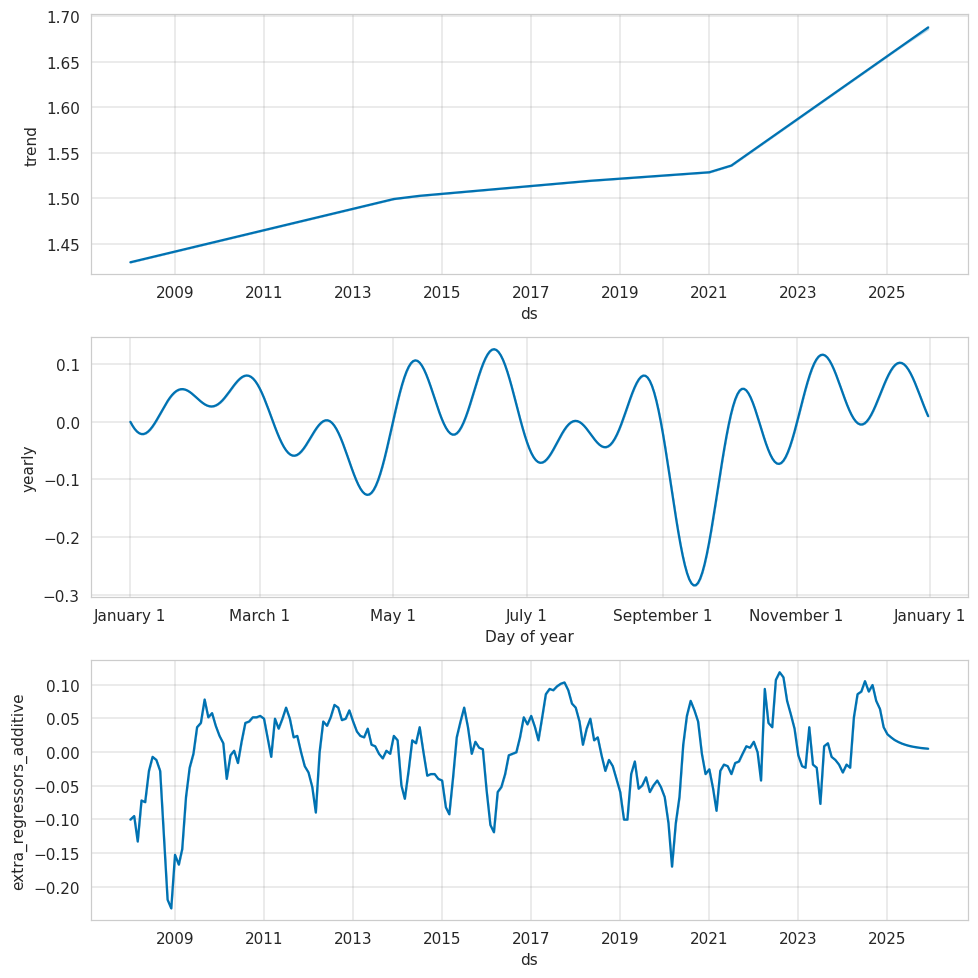

Period      |      MAE |     RMSE |    MAPE |      R2
----------------------------------------------------
Overall     |    37.83 |    51.78 |   4.82% |  0.9853
Pre-2022    |    31.23 |    38.14 |   4.94% |  0.9326
Post-2022   |    68.23 |    91.30 |   4.27% |  0.8746


In [23]:
from prophet import Prophet
dfp = df[['log_Export_Price_USD','log_Global_Price']].reset_index().rename(
        columns={'Date':'ds','log_Export_Price_USD':'y','log_Global_Price':'global_price'})
m_usd = Prophet(growth='linear', yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, changepoint_prior_scale=0.05)
m_usd.add_regressor('global_price'); m_usd.fit(dfp)
future = m_usd.make_future_dataframe(periods=steps, freq='MS')
future['global_price'] = dfp['global_price'].tolist() + list(glob_oos['mean'].values)
forecast_p = m_usd.predict(future)
m_usd.plot_components(forecast_p); plt.tight_layout(); plt.show()

df_p = df.copy()
df_p['prophet_usd_log'] = forecast_p.set_index('ds').reindex(df_p.index)['yhat']
df_p['prophet_lkr'] = np.exp(df_p['prophet_usd_log'] + df_p['fx_forecast'])
print(f'{"Period":<12}| {"MAE":>8} | {"RMSE":>8} | {"MAPE":>7} | {"R2":>7}'); print('-'*52)
for label,mm in periods:
    mae,rmse,mape,r2=calculate_metrics(df_p.loc[mm,'Export Price (LKR/kg)'], df_p.loc[mm,'prophet_lkr'])
    print(f'{label:<12}| {mae:>8.2f} | {rmse:>8.2f} | {mape:>6.2f}% | {r2:>7.4f}')

### 11.1 Prophet hybrid forecast (connected)

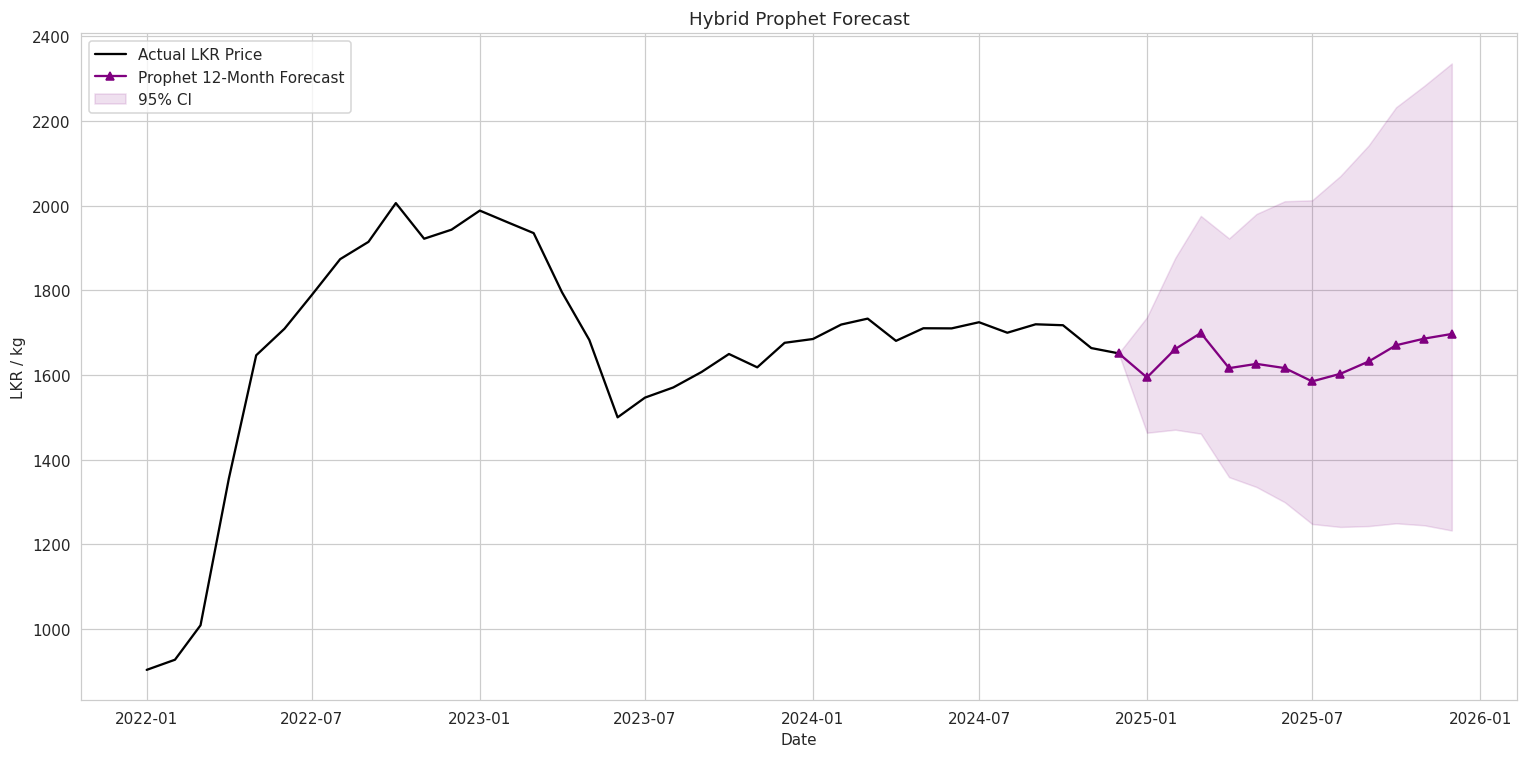

In [24]:
p2025 = forecast_p.set_index('ds').loc[future_dates[0]:]
mean_log = p2025['yhat'].values + fx_oos['mean'].values
se_p = (p2025['yhat_upper'].values - p2025['yhat'].values)/Z
se_tot = np.sqrt(se_p**2 + se_from_summary(fx_oos)**2)
prop_lkr=np.exp(mean_log); prop_lo=np.exp(mean_log-Z*se_tot); prop_hi=np.exp(mean_log+Z*se_tot)
ci,cv=connect(hist.index,hist.values,future_dates,prop_lkr)
_,clo=connect(hist.index,hist.values,future_dates,prop_lo); _,chi=connect(hist.index,hist.values,future_dates,prop_hi)
plt.figure(figsize=(14,7))
plt.plot(df.index[-36:], hist.iloc[-36:], color='black', label='Actual LKR Price')
plt.plot(ci,cv,color='purple',marker='^',markersize=5,label='Prophet 12-Month Forecast')
plt.fill_between(ci,clo,chi,color='purple',alpha=0.12,label='95% CI')
plt.title('Hybrid Prophet Forecast'); plt.xlabel('Date'); plt.ylabel('LKR / kg')
plt.legend(loc='upper left'); plt.tight_layout(); plt.show()

## 12. Benchmark comparison

                   MAE    RMSE  MAPE%     R2
Model                                       
SARIMAX         19.933  30.813  2.324  0.995
XGBoost (test)  41.817  57.799  2.979  0.983
Prophet         37.826  51.777  4.823  0.985


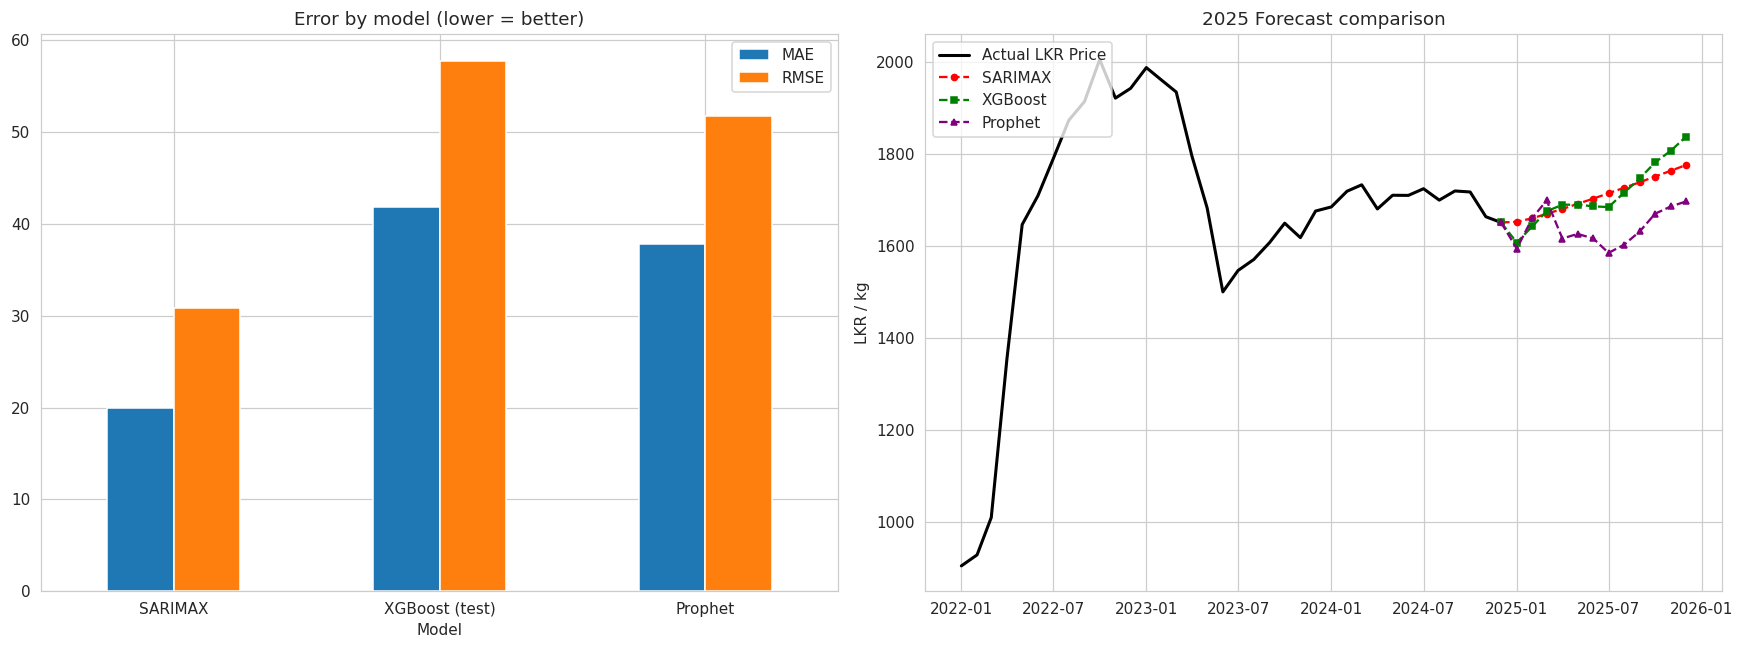

In [25]:
rows=[('SARIMAX',*calculate_metrics(df.loc[mask,'Export Price (LKR/kg)'],df.loc[mask,'lkr_forecast_real'])),
      ('XGBoost (test)',*calculate_metrics(df.loc[idx,'Export Price (LKR/kg)'],xgb_lkr)),
      ('Prophet',*calculate_metrics(df_p.loc[df_p.index[2:],'Export Price (LKR/kg)'],df_p.loc[df_p.index[2:],'prophet_lkr']))]
bench=pd.DataFrame(rows,columns=['Model','MAE','RMSE','MAPE%','R2']).set_index('Model').round(3)
print(bench)

fig, ax = plt.subplots(1, 2, figsize=(16,6))
bench[['MAE','RMSE']].plot(kind='bar', ax=ax[0]); ax[0].set_title('Error by model (lower = better)'); ax[0].tick_params(axis='x',rotation=0)
ax[1].plot(df.index[-36:], hist.iloc[-36:], color='black', lw=2, label='Actual LKR Price')
for fc,c,mk,lab in [(lkr_sarimax,'red','o','SARIMAX'),(xgb_oos,'green','s','XGBoost'),(prop_lkr,'purple','^','Prophet')]:
    ci,cv=connect(hist.index,hist.values,future_dates,fc)
    ax[1].plot(ci,cv,color=c,marker=mk,markersize=4,linestyle='--',label=lab)
ax[1].set_title('2025 Forecast comparison'); ax[1].set_ylabel('LKR / kg'); ax[1].legend(loc='upper left')
plt.tight_layout(); plt.show()